## Load the Data

In [5]:
import sys
import os

# Add the src/piccard directory to Python path
current_dir = os.getcwd()  # Get current working directory
src_piccard_path = os.path.join(current_dir, '..', 'src', 'piccard')
sys.path.append(os.path.abspath(src_piccard_path))
# Now you can import VariableLinker
from linking.variable_linker import VariableLinker

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aam20\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
import os
import subprocess

# Clone the repo (only if not already cloned)
if not os.path.exists("ppandas"):
    subprocess.run(["git", "clone", "https://github.com/D3Mlab/ppandas"])

# Change directory
os.chdir("ppandas/ppandas")

!pip install pgmpy
!pip install intervals
!pip install geovoronoi
!pip install yellowbrick
from p_frame import PDataFrame

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [7]:
import sys
import os

# Check current working directory
print("Current working directory:", os.getcwd())

# Go up 3 levels to reach project root, then into src
src_path = os.path.abspath('../../../src')
print("Src path:", src_path)
print("Src path exists:", os.path.exists(src_path))

# Add to Python path
if os.path.exists(src_path):
    sys.path.append(src_path)
    print("Added src to path successfully")
    
    # List contents to verify
    print("Contents of src folder:", os.listdir(src_path))
    
    # Now try importing
    try:
        from piccard import piccard2 as pc2
        print("Successfully imported piccard2!")
    except ImportError as e:
        print(f"Import error: {e}")
        # Try alternative imports
        try:
            import piccard2 as pc2
            print("Successfully imported piccard2 directly!")
        except ImportError as e2:
            print(f"Direct import also failed: {e2}")
else:
    print("Src folder still not found!")

Current working directory: c:\Users\aam20\OneDrive - KFUPM\Abdulmohseen\KAUST - AI\KAUST-Summer\Toronto Work\piccard2\docs\ppandas\ppandas
Src path: c:\Users\aam20\OneDrive - KFUPM\Abdulmohseen\KAUST - AI\KAUST-Summer\Toronto Work\piccard2\src
Src path exists: True
Added src to path successfully
Contents of src folder: ['piccard']
Import error: cannot import name 'piccard2' from 'piccard' (c:\Users\aam20\OneDrive - KFUPM\Abdulmohseen\KAUST - AI\KAUST-Summer\Toronto Work\piccard2\src\piccard\piccard.py)
Direct import also failed: No module named 'piccard2'


In [10]:
import sys
import os

# Add the "src" folder to sys.path (assuming you're in docs/ppandas)
sys.path.append(os.path.abspath('../../src'))

# Import correctly
import piccard as pc2

# install other dependencies, pip install first if needed
from tscluster.tsplot import tsplot
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Union
from plotly.subplots import make_subplots
import math
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd # for type annotations
import warnings
warnings.filterwarnings('ignore')

In [11]:
# Load the census metadata for each year, and preprocessing each of them
data_2006 = pc2.preprocess_census_metadata("../../../docs/piccard2_testing_data/census_ca06_full_metadata.json")
data_2011 = pc2.preprocess_census_metadata("../../../docs/piccard2_testing_data/census_ca11_full_metadata.json")
data_2016 = pc2.preprocess_census_metadata("../../../docs/piccard2_testing_data/census_ca16_full_metadata.json")
data_2021 = pc2.preprocess_census_metadata("../../../docs/piccard2_testing_data/census_ca21_full_metadata.json")

The unique values for the type were:  ['Total' 'Male' 'Female'] and now it is:  ['Total']
The unique values for the type were:  ['Total' 'Male' 'Female'] and now it is:  ['Total']
The unique values for the type were:  ['Total' 'Male' 'Female'] and now it is:  ['Total']
The unique values for the type were:  ['Total' 'Male' 'Female'] and now it is:  ['Total']


In [12]:
data_2016.head()

,vector,description,type,units,parent_vector,aggregation,details
0,v_CA16_401,"Population, 2016",Total,Number,None,Additive,CA 2016 Census; Population and Dwellings; Popu...
1,v_CA16_402,"Population, 2011",Total,Number,None,Additive,CA 2016 Census; Population and Dwellings; Popu...
2,v_CA16_403,"Population percentage change, 2011 to 2016",Total,Number,None,Average of v_CA16_402,CA 2016 Census; Population and Dwellings; Popu...
3,v_CA16_404,Total private dwellings,Total,Number,None,Additive,CA 2016 Census; Population and Dwellings; Tota...
4,v_CA16_405,Private dwellings occupied by usual residents,Total,Number,v_CA16_404,Additive,CA 2016 Census; Population and Dwellings; Tota...


In [13]:
print("The number of vectors in 2006 is:", len(data_2006))
print("The number of vectors in 2011 is:", len(data_2011))
print("The number of vectors in 2016 is:", len(data_2016))
print("The number of vectors in 2021 is:", len(data_2021))

The number of vectors in 2006 is: 1565
The number of vectors in 2011 is: 1429
The number of vectors in 2016 is: 2347
The number of vectors in 2021 is: 2723


-------------------------------

## Jaccard Matching Approach

In [ ]:
# Match descriptions between 2021 and 2016, 2011, and 2006 using Jaccard similarity
# the process will be applied to all years compared with 2021 -> can be changed to any year but it is suggested to use the latest year
jaccard_mapping_21_16 = pc2.match_descriptions_jaccard(source_df=data_2021, compare_df=data_2016, similarity_threshold=0.9)
jaccard_mapping_21_11 = pc2.match_descriptions_jaccard(source_df=data_2021, compare_df=data_2011, similarity_threshold=0.9)
jaccard_mapping_21_06 = pc2.match_descriptions_jaccard(source_df=data_2021, compare_df=data_2006, similarity_threshold=0.9)


### Merge All DataFrames into One DataFrame

In [ ]:
# After matching descriptions, we can merge the mappings into a single dataframe to be used for the tree visualization
jaccard_merged_df = pc2.merge_mappings(data_2021, jaccard_mapping_21_16, jaccard_mapping_21_11, jaccard_mapping_21_06)
print(f"Base data (2021): {len(data_2021)} rows")
print(f"Merged result: {len(jaccard_merged_df)} rows")

In [ ]:
# Build the tree using the Jaccard similarity mapping and save it in the trees folder
tree_name = "jaccard_tree"
tree_path = "C:/Users/aam20/OneDrive - KFUPM/Abdulmohseen/KAUST - AI/KAUST-Summer/Toronto Work/piccard2/trees"
jaccard_tree = pc2.build_tree(data_2021, jaccard_merged_df, tree_name, tree_path)

-------------------

## Multithreaded Approach

In [ ]:

# match descriptions between 2021 and 2016, 2011, and 2006 using multithreaded approach
# the process will be applied to all years compared with 2021 -> can be changed to any year but it is suggested to use the latest year
# the main difference between this and the single-threaded approach is that this will use all the cores of the machine to process the data
# and this will reslut in a faster processing time giving the same result
multithreaded_mapping_21_16 = pc2.match_descriptions_multithreaded(source_df=data_2021, compare_df=data_2016, similarity_threshold=0.9, max_workers=8)
multithreaded_mapping_21_11 = pc2.match_descriptions_multithreaded(source_df=data_2021, compare_df=data_2011, similarity_threshold=0.9, max_workers=8)
multithreaded_mapping_21_06 = pc2.match_descriptions_multithreaded(source_df=data_2021, compare_df=data_2006, similarity_threshold=0.9, max_workers=8)

### Merge All DataFrames into One DataFrame

In [ ]:
# Merge the multithreaded mapping results into a single dataframe as this will be used to build the tree
multithreaded_merged_df = pc2.merge_mappings(data_2021, multithreaded_mapping_21_16, multithreaded_mapping_21_11, multithreaded_mapping_21_06)
print(f"Base data (2021): {len(data_2021)} rows")
print(f"Merged result: {len(multithreaded_merged_df)} rows")

In [ ]:
# Build the tree using the multithreaded mapping and save it in the trees folder
tree_name = "multithreaded_tree"
multithreaded_tree = pc2.build_tree(data_2021, multithreaded_merged_df, tree_name, tree_path)

-----------------------------------------

## Transformer Approach#1

In [14]:
# Match descriptions between 2021 and 2016, 2011, and 2006 using sentence transformers
# the process will be applied to all years compared with 2021 -> can be changed to any year but it is suggested to use the latest year
# the main difference between this and the previous approach is that this will utlize the power of LLMs by encoding the descriptions and then using the cosine similarity to find the best match
# this appraoch may enhance the accuricy in some feilds as it look into the meaning of the descriptions rather than the words
# Moreover, this appraoch is faster than the previous one as it uses vectorization to find the best match
transformer_mapping_21_16 = pc2.match_descriptions_transformer(data_2021, data_2016, similarity_threshold=0.9)
transformer_mapping_21_11 = pc2.match_descriptions_transformer(data_2021, data_2011, similarity_threshold=0.9)
transformer_mapping_21_06 = pc2.match_descriptions_transformer(data_2021, data_2006, similarity_threshold=0.9)

INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: all-mpnet-base-v2


Number of exact matches: 1736


Batches: 100%|██████████| 20/20 [00:06<00:00,  2.98it/s]
INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: all-mpnet-base-v2


Number of exact matches: 1902
Number of exact matches: 892


Batches: 100%|██████████| 17/17 [00:05<00:00,  3.16it/s]
INFO:sentence_transformers.SentenceTransformer:Use pytorch device_name: cpu
INFO:sentence_transformers.SentenceTransformer:Load pretrained SentenceTransformer: all-mpnet-base-v2


Number of exact matches: 1009
Number of exact matches: 679


Batches: 100%|██████████| 28/28 [00:08<00:00,  3.38it/s]


Number of exact matches: 784


### Merge All DataFrames into One DataFrame

In [15]:
# Merge the transformer mapping results into a single dataframe as this will be used to build the tree
transformer_merged_df = pc2.merge_mappings(data_2021, transformer_mapping_21_16, transformer_mapping_21_11, transformer_mapping_21_06)
print(f"Base data (2021): {len(data_2021)} rows")
print(f"Merged result: {len(transformer_merged_df)} rows")

Base data (2021): 2723 rows
Merged result: 1990 rows


In [16]:
# Build the tree using the transformer mapping and save it in the trees folder
tree_name = "transformer_tree"
tree_path = "C:/Users/aam20/OneDrive - KFUPM/Abdulmohseen/KAUST - AI/KAUST-Summer/Toronto Work/piccard2/trees"

transformer_tree = pc2.build_tree(data_2021, transformer_merged_df, tree_name, tree_path)

----------------

## Transformer Approach#2 -> using details

In [ ]:
# Match descriptions between 2021 and 2016, 2011, and 2006 using sentence transformers
# this is similar to the previous approach but it uses the details of the descriptions to find the best match
# the details section will be used to find the best match in case of multiple matches in the exact match

transformer_advanced_mapping_21_16 = pc2.match_descriptions_details_sentence_transformer(data_2021, data_2016, similarity_threshold=0.9)
transformer_advanced_mapping_21_11 = pc2.match_descriptions_details_sentence_transformer(data_2021, data_2011, similarity_threshold=0.9)
transformer_advanced_mapping_21_06 = pc2.match_descriptions_details_sentence_transformer(data_2021, data_2006, similarity_threshold=0.9)

### Merge All DataFrames into One DataFrame

In [ ]:
# Merge the transformer advanced mapping results into a single dataframe as this will be used to build the tree
transformer_advanced_merged_df = pc2.merge_mappings(data_2021, transformer_advanced_mapping_21_16, transformer_advanced_mapping_21_11, transformer_advanced_mapping_21_06)
print(f"Base data (2021): {len(data_2021)} rows")
print(f"Merged result: {len(transformer_advanced_merged_df)} rows")

In [ ]:
# Building the tree using the transformer advanced mapping
tree_name = "transformer_advanced_tree" 
transformer_advanced_tree = pc2.build_tree(data_2021, transformer_advanced_merged_df, tree_name, tree_path)

# Evaluation

In [18]:
# Usage
dict_jaccard = pc2.parse_tree_to_dict('../../../trees/jaccard_tree')
dict_transformer = pc2.parse_tree_to_dict('../../../trees/transformer_tree')
dict_advanced_transformer = pc2.parse_tree_to_dict('../../../trees/transformer_advanced_tree')

print("Number of vectors in Jaccard tree: ", len(dict_jaccard))
print("Number of vectors in Transformer tree: ", len(dict_transformer))
print("Number of vectors in Advanced Transformer tree: ", len(dict_advanced_transformer))



Number of vectors in Jaccard tree:  2723
Number of vectors in Transformer tree:  2723
Number of vectors in Advanced Transformer tree:  2723


In [19]:
import requests
from bs4 import BeautifulSoup
def get_vector_by_description(description, data_df):
    if description == "Not available":
        return "Not available"
    # Try exact match
    match = data_df[data_df['description'] == description]
    if not match.empty:
        return match.iloc[0]['vector']
    # Try substring match
    match = data_df[data_df['description'].str.contains(description, na=False)]
    if not match.empty:
        return match.iloc[0]['vector']
    return None

def get_clean_text(cell):
    for sup in cell.find_all('sup'):
        sup.decompose()
    for span in cell.find_all('span'):
        span.decompose()
    for a in cell.find_all('a'):
        a.decompose()
    # Use separator=" " to ensure spaces between text nodes
    return cell.get_text(separator=" ", strip=True)
    
def parse_table_data_from_url(url: str, data_dict: dict, row_class: str = 'highlight-row'):
    """
    Parse table data from a URL and map descriptions to vectors for any number of years.
    
    Args:
        url (str): URL to fetch HTML data from
        data_dict (dict): Dictionary with year keys and DataFrame values
                         e.g., {'2021': data_2021, '2016': data_2016, '2011': data_2011}
        row_class (str): CSS class name for table rows to parse (default: 'highlight-row')
        
    Returns:
        dict: Dictionary mapping source year vectors to other years' vectors
    """
    # Fetch HTML content from URL
    response = requests.get(url)
    response.raise_for_status()
    html = response.text
    
    soup = BeautifulSoup(html, 'html.parser')
    
    # Initialize the dictionary
    result_dict = {}
    
    # Get the source year (first year in data_dict)
    source_year = list(data_dict.keys())[0]
    other_years = list(data_dict.keys())[1:]
    
    # Loop through each row
    print(f"Number of vectors in table data: {len(soup.find_all('tr', class_=row_class))}")
    for row in soup.find_all('tr', class_=row_class):
        cells = row.find_all(['th', 'td'])
        if len(cells) == len(data_dict):  # Check if we have enough columns
            # Get source year description
            source_description = get_clean_text(cells[0])
            
            # Get vector names for all years
            source_vector = get_vector_by_description(source_description, data_dict[source_year])
            
            if source_vector is not None:
                # Initialize year mapping
                year_mapping = {}
                
                # Map each other year
                for i, year in enumerate(other_years, 1):
                    if i < len(cells):
                        year_description = get_clean_text(cells[i])
                        year_vector = get_vector_by_description(year_description, data_dict[year])
                        year_mapping[year] = year_vector
                
                result_dict[source_vector] = year_mapping

    print(f"Number of valid vectors in table data: {len(result_dict)}")
    return result_dict

In [20]:
url = "https://www12.statcan.gc.ca/census-recensement/2021/ref/dict/app/index-eng.cfm?ID=a2_2"
language_data = {'2021': data_2021, '2016': data_2016, '2011': data_2011}
language_dict = parse_table_data_from_url(url, language_data)

Number of vectors in table data: 537
Number of valid vectors in table data: 322


In [21]:
import pandas as pd
def evaluate_tree(tree_dict, gt_dict):
    """
    Evaluate tree predictions against ground truth for any number of years.
    
    Args:
        tree_dict (dict): Dictionary with predicted mappings
                         Format: {vector_2021: {'2016': pred_2016, '2011': pred_2011}}
        gt_dict (dict): Dictionary with ground truth mappings
                       Format: {vector_2021: {'2016': gt_2016, '2011': gt_2011}}
        
    Returns:
        pd.DataFrame: DataFrame with evaluation results for each year
    """
    # Get all years from ground truth (excluding the source year)
    years = list(gt_dict.values())[0].keys() if gt_dict else []
    
    # Initialize results dictionary
    results = {}
    
    for year in years:
        correct = 0
        miss = 0
        
        for vector_2021, gt in gt_dict.items():
            pred = tree_dict.get(vector_2021, {})
            
            gt_year = gt.get(year)
            pred_year = pred.get(year)
            
            if gt_year not in [None, "Not available"]:
                if pred_year == gt_year:
                    correct += 1
                else:
                    miss += 1
            else:
                if pred_year is not None:
                    miss += 1
                else:
                    correct += 1
        
        results[year] = [correct, miss]
    
    return pd.DataFrame(results, index=["Correct", "Miss"])

In [22]:
results_jaccard = evaluate_tree(dict_jaccard, language_dict)
results_transformer = evaluate_tree(dict_transformer, language_dict)
results_advanced_transformer = evaluate_tree(dict_advanced_transformer, language_dict)

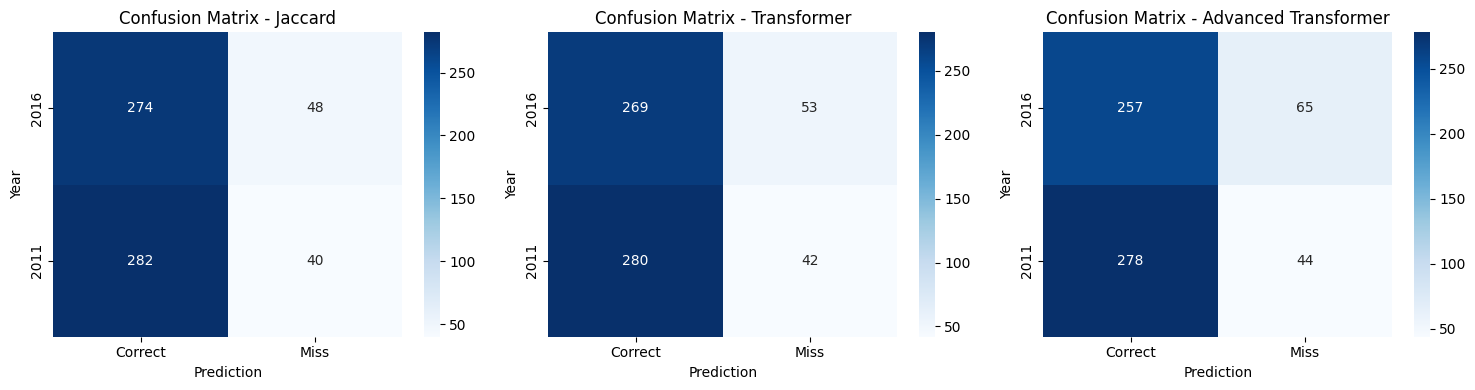

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with 1 row and 3 columns of subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot Jaccard confusion matrix
sns.heatmap(results_jaccard.T, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Jaccard")
axes[0].set_xlabel("Prediction")
axes[0].set_ylabel("Year")

# Plot Transformer confusion matrix
sns.heatmap(results_transformer.T, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix - Transformer")
axes[1].set_xlabel("Prediction")
axes[1].set_ylabel("Year")

# Plot Advanced Transformer confusion matrix
sns.heatmap(results_advanced_transformer.T, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Confusion Matrix - Advanced Transformer")
axes[2].set_xlabel("Prediction")
axes[2].set_ylabel("Year")

plt.tight_layout()
plt.show()

In [24]:
url = "https://www12.statcan.gc.ca/census-recensement/2021/ref/dict/app/index-eng.cfm?ID=A2_5"
ethnic_data = {'2021': data_2021, '2016': data_2016, '2011': data_2011}
ethnic_dict = parse_table_data_from_url(url, ethnic_data)

Number of vectors in table data: 503
Number of valid vectors in table data: 294


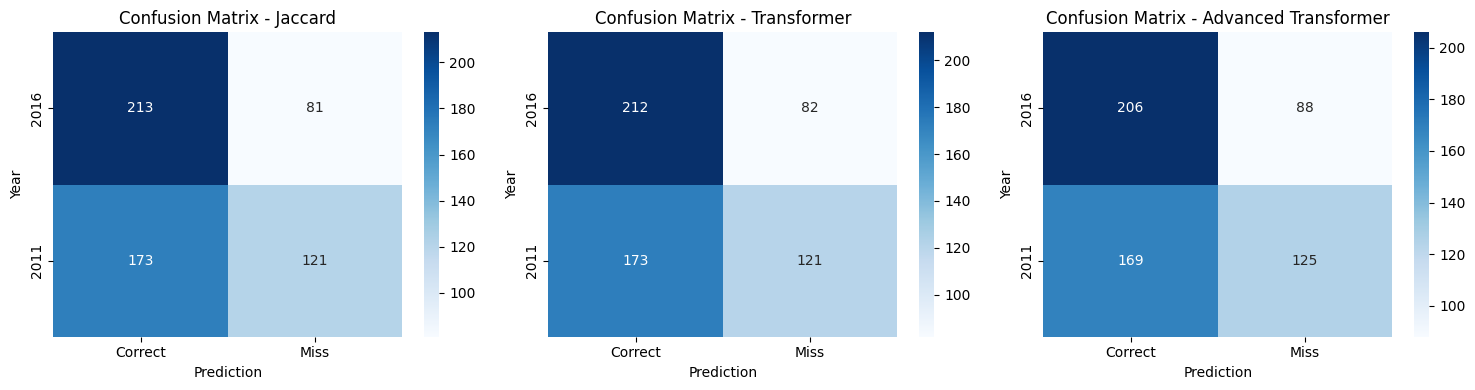

In [25]:
results_jaccard = evaluate_tree(dict_jaccard, ethnic_dict)
results_transformer = evaluate_tree(dict_transformer, ethnic_dict)
results_advanced_transformer = evaluate_tree(dict_advanced_transformer, ethnic_dict)

import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with 1 row and 3 columns of subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot Jaccard confusion matrix
sns.heatmap(results_jaccard.T, annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion Matrix - Jaccard")
axes[0].set_xlabel("Prediction")
axes[0].set_ylabel("Year")

# Plot Transformer confusion matrix
sns.heatmap(results_transformer.T, annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion Matrix - Transformer")
axes[1].set_xlabel("Prediction")
axes[1].set_ylabel("Year")

# Plot Advanced Transformer confusion matrix
sns.heatmap(results_advanced_transformer.T, annot=True, fmt="d", cmap="Blues", ax=axes[2])
axes[2].set_title("Confusion Matrix - Advanced Transformer")
axes[2].set_xlabel("Prediction")
axes[2].set_ylabel("Year")

plt.tight_layout()
plt.show()


# Suggestions

In [26]:
tree_dict = pc2.parse_tree_to_dict('../../../trees/transformer_tree')
parent_child_relationships = pc2.extract_parent_child_relationships('../../../trees/transformer_tree')
predictions = pc2.predict_parent_nodes(tree_dict, parent_child_relationships, ['2016', '2011', '2006'])


In [27]:
# Generate report
print("=== Tree Analysis Report ===")
print(f"Total nodes in tree: {len(tree_dict)}")
print(f"Parent-child relationships: {len(parent_child_relationships)}")
print(f"Predictable parent nodes: {len(predictions)}")

for parent, years in predictions.items():
    parent_desc = tree_dict[parent]['description']
    print(f"\nParent: {parent_desc}")
    print(f"  Node ID: {parent}")
    print(f"  Predictable in years: {years}")

=== Tree Analysis Report ===
Total nodes in tree: 2723
Parent-child relationships: 513
Predictable parent nodes: 79

Parent: 0 to 14 years
  Node ID: v_CA21_11
  Predictable in years: ['2011']

Parent: 65 years and over
  Node ID: v_CA21_251
  Predictable in years: ['2006']

Parent: v_CA21_531
  Node ID: v_CA21_531
  Predictable in years: ['2011', '2006']

Parent: One-census-family ho...
  Node ID: v_CA21_544
  Predictable in years: ['2006']

Parent: v_CA21_492
  Node ID: v_CA21_492
  Predictable in years: ['2016']

Parent: Total couple familie...
  Node ID: v_CA21_500
  Predictable in years: ['2011', '2006']

Parent: v_CA21_557
  Node ID: v_CA21_557
  Predictable in years: ['2016']

Parent: v_CA21_665
  Node ID: v_CA21_665
  Predictable in years: ['2016']

Parent: After-tax income gro...
  Node ID: v_CA21_713
  Predictable in years: ['2011', '2006']

Parent: Income statistics fo...
  Node ID: v_CA21_908
  Predictable in years: ['2016']

Parent: v_CA21_911
  Node ID: v_CA21_911
  Predi

In [28]:
print(len(predictions))
print(predictions["v_CA21_3517"])
print(predictions["v_CA21_4186"])

count = 0
for key, value in predictions.items():
    count += 1
    if count > 10:
        break
    print(key, value)

79
['2016']
['2011', '2006']
v_CA21_11 ['2011']
v_CA21_251 ['2006']
v_CA21_531 ['2011', '2006']
v_CA21_544 ['2006']
v_CA21_492 ['2016']
v_CA21_500 ['2011', '2006']
v_CA21_557 ['2016']
v_CA21_665 ['2016']
v_CA21_713 ['2011', '2006']
v_CA21_908 ['2016']
